In [1]:
!pip install pymc bambi arviz

   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ---------------------------------------- 584.2/584.2 kB 7.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 11.0 MB/s  0:00:00

   -- -------------------------------------  1/15 [graphviz]
   ----- ----------------------------------  2/15 [sparse]
   ----- ----------------------------------  2/15 [sparse]
   ----- ----------------------------------  2/15 [sparse]
   ----- ----------------------------------  2/15 [sparse]
   ----- ----------------------------------  2/15 [sparse]
   ----- ----------------------------------  2/15 [sparse]
   ---------- -----------------------------  4/15 [arviz_stats]
   ---------- -----------------------------  4/15 [arviz_stats]
   ------------- -----

In [3]:
import pymc as pm
import bambi as bmb
import arviz as az
import numpy as np
import pandas as pd

# Reload clean data
df_clean = pd.read_csv('ratings_clean_v3.csv')
df_clean = df_clean.copy()

# Recalculate model means
dimensions = ['clarity', 'appropriateness', 'accuracy', 'consistency', 'empathy']
models = ['model_a', 'model_b', 'model_c']
model_names_map = {'model_a': 'GPT-4', 'model_b': 'Claude', 'model_c': 'Groq/Llama 3'}

for model in models:
    cols = [f'{model}_{d}' for d in dimensions]
    df_clean[f'{model}_mean'] = df_clean[cols].mean(axis=1)

# Create long format dataframe
rows = []
for _, row in df_clean.iterrows():
    for model in models:
        for dim in dimensions:
            rows.append({
                'rater': row['evaluator_name'],
                'prompt_idx': row['prompt_idx'],
                'model': model_names_map[model],
                'dimension': dim,
                'score': row[f'{model}_{dim}']
            })

df_long = pd.DataFrame(rows)
print(f"Long format shape: {df_long.shape}")
print(f"Models: {df_long['model'].unique()}")
print(f"\nMean scores by model:")
print(df_long.groupby('model')['score'].mean().round(3))

Long format shape: (11700, 5)
Models: ['GPT-4' 'Claude' 'Groq/Llama 3']

Mean scores by model:
model
Claude          3.696
GPT-4           3.814
Groq/Llama 3    3.761
Name: score, dtype: float64


In [4]:
# Step 1: Overall Bayesian model comparison
# Using a hierarchical model with rater and prompt as random effects

print("Building Bayesian model for overall model comparison...")
print("This may take a few minutes...\n")

# Encode model as numeric
model_codes = {'GPT-4': 0, 'Claude': 1, 'Groq/Llama 3': 2}
df_long['model_code'] = df_long['model'].map(model_codes)

# Encode rater and prompt as numeric
df_long['rater_code'] = pd.Categorical(df_long['rater']).codes
df_long['prompt_code'] = pd.Categorical(df_long['prompt_idx']).codes

n_models = 3
n_raters = df_long['rater_code'].nunique()
n_prompts = df_long['prompt_code'].nunique()

print(f"Models: {n_models}")
print(f"Raters: {n_raters}")
print(f"Prompts: {n_prompts}")
print(f"Total observations: {len(df_long)}")

with pm.Model() as overall_model:
    # Priors for model effects
    mu_model = pm.Normal('mu_model', mu=3.5, sigma=1, shape=n_models)
    
    # Random effects for raters
    sigma_rater = pm.HalfNormal('sigma_rater', sigma=0.5)
    rater_offset = pm.Normal('rater_offset', mu=0, sigma=sigma_rater, 
                              shape=n_raters)
    
    # Random effects for prompts
    sigma_prompt = pm.HalfNormal('sigma_prompt', sigma=0.5)
    prompt_offset = pm.Normal('prompt_offset', mu=0, sigma=sigma_prompt,
                               shape=n_prompts)
    
    # Observation noise
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    # Expected value
    mu = (mu_model[df_long['model_code'].values] + 
          rater_offset[df_long['rater_code'].values] +
          prompt_offset[df_long['prompt_code'].values])
    
    # Likelihood
    score = pm.Normal('score', mu=mu, sigma=sigma, 
                       observed=df_long['score'].values)
    
    # Sample
    trace = pm.sample(2000, tune=1000, chains=4, 
                      target_accept=0.9, 
                      return_inferencedata=True,
                      progressbar=True)

print("\nSampling complete!")

Building Bayesian model for overall model comparison...
This may take a few minutes...

Models: 3
Raters: 13
Prompts: 60
Total observations: 11700


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 89 seconds.



Sampling complete!


In [6]:
print("BAYESIAN MODEL COMPARISON — OVERALL RESULTS")

model_names_list = ['GPT-4', 'Claude', 'Groq/Llama 3']
posterior_mu = trace.posterior['mu_model']

print("\nPosterior Mean Scores with 95% Credible Intervals:\n")
print(f"{'Model':<15} {'Mean':>8} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")

means = []
for i, name in enumerate(model_names_list):
    samples = posterior_mu.values[:, :, i].flatten()
    mean = samples.mean()
    hdi = az.hdi(samples, prob=0.95)
    means.append(mean)
    print(f"{name:<15} {mean:>8.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

# Pairwise probability comparisons
print("\nProbability of Difference (Bayesian pairwise):\n")
print(f"{'Comparison':<35} {'P(A>B)':>8} {'Mean Diff':>10} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")

pairs = [
    ('GPT-4', 'Claude', 0, 1),
    ('GPT-4', 'Groq/Llama 3', 0, 2),
    ('Claude', 'Groq/Llama 3', 1, 2),
]

for name_a, name_b, i, j in pairs:
    samples_a = posterior_mu.values[:, :, i].flatten()
    samples_b = posterior_mu.values[:, :, j].flatten()
    diff = samples_a - samples_b
    prob = (diff > 0).mean()
    mean_diff = diff.mean()
    hdi = az.hdi(diff, prob=0.95)
    print(f"{name_a+' vs '+name_b:<35} {prob:>8.3f} {mean_diff:>10.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

print("\nConvergence Diagnostics:")
print(az.summary(trace, var_names=['mu_model'], round_to=3))

BAYESIAN MODEL COMPARISON — OVERALL RESULTS

Posterior Mean Scores with 95% Credible Intervals:

Model               Mean   HDI 2.5%  HDI 97.5%
GPT-4              3.785      3.402      4.164
Claude             3.668      3.286      4.043
Groq/Llama 3       3.733      3.358      4.124

Probability of Difference (Bayesian pairwise):

Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.117      0.077      0.157
GPT-4 vs Groq/Llama 3                  0.995      0.052      0.013      0.093
Claude vs Groq/Llama 3                 0.001     -0.064     -0.104     -0.026

Convergence Diagnostics:
              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
mu_model[0]  3.785  0.193     3.471     4.090   706.693  1113.121  1.007   
mu_model[1]  3.668  0.193     3.353     3.973   707.525  1090.125  1.008   
mu_model[2]  3.733  0.193     3.420     4.036   708.445  1112.956  1.007   

             mcse_mean 

In [7]:
# Merge with prompt metadata
prompts_df = pd.read_csv(r'C:\Users\kehin\Downloads\model_outputs.csv')[['prompt_id', 'disability_type', 'task_type']]
prompts_df['prompt_idx'] = prompts_df.index

df_long_merged = df_long.merge(
    prompts_df, 
    left_on='prompt_idx', 
    right_on='prompt_idx', 
    how='left'
)

print("Disability type distribution:")
print(df_long_merged['disability_type'].value_counts())

disability_types = ['AAC', 'intellectual_disability', 'aphasia']
results = {}

for disability in disability_types:
    print(f"Running Bayesian model for: {disability}")
    
    subset = df_long_merged[df_long_merged['disability_type'] == disability].copy()
    subset['rater_code'] = pd.Categorical(subset['rater']).codes
    subset['prompt_code'] = pd.Categorical(subset['prompt_idx']).codes
    
    n_raters_sub = subset['rater_code'].nunique()
    n_prompts_sub = subset['prompt_code'].nunique()
    
    with pm.Model() as disability_model:
        mu_model = pm.Normal('mu_model', mu=3.5, sigma=1, shape=3)
        
        sigma_rater = pm.HalfNormal('sigma_rater', sigma=0.5)
        rater_offset = pm.Normal('rater_offset', mu=0, sigma=sigma_rater,
                                  shape=n_raters_sub)
        
        sigma_prompt = pm.HalfNormal('sigma_prompt', sigma=0.5)
        prompt_offset = pm.Normal('prompt_offset', mu=0, sigma=sigma_prompt,
                                   shape=n_prompts_sub)
        
        sigma = pm.HalfNormal('sigma', sigma=1)
        
        mu = (mu_model[subset['model_code'].values] +
              rater_offset[subset['rater_code'].values] +
              prompt_offset[subset['prompt_code'].values])
        
        score = pm.Normal('score', mu=mu, sigma=sigma,
                           observed=subset['score'].values)
        
        trace_d = pm.sample(2000, tune=1000, chains=4,
                            target_accept=0.9,
                            return_inferencedata=True,
                            progressbar=False)
    
    results[disability] = trace_d
    
    posterior_mu = trace_d.posterior['mu_model']
    print(f"\nPosterior means — {disability}:")
    print(f"{'Model':<15} {'Mean':>8} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
    for i, name in enumerate(model_names_list):
        samples = posterior_mu.values[:, :, i].flatten()
        mean = samples.mean()
        hdi = az.hdi(samples, prob=0.95)
        print(f"{name:<15} {mean:>8.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")
    
    print(f"\nPairwise probabilities — {disability}:")
    print(f"{'Comparison':<35} {'P(A>B)':>8} {'Mean Diff':>10} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
    for name_a, name_b, i, j in pairs:
        samples_a = posterior_mu.values[:, :, i].flatten()
        samples_b = posterior_mu.values[:, :, j].flatten()
        diff = samples_a - samples_b
        prob = (diff > 0).mean()
        mean_diff = diff.mean()
        hdi = az.hdi(diff, prob=0.95)
        print(f"{name_a+' vs '+name_b:<35} {prob:>8.3f} {mean_diff:>10.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

print("\nAll disability models complete!")

Disability type distribution:
disability_type
AAC                        4875
intellectual_disability    3900
aphasia                    2925
Name: count, dtype: int64
Running Bayesian model for: AAC


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 45 seconds.



Posterior means — AAC:
Model               Mean   HDI 2.5%  HDI 97.5%
GPT-4              3.832      3.469      4.218
Claude             3.817      3.438      4.181
Groq/Llama 3       3.864      3.501      4.246

Pairwise probabilities — AAC:
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        0.688      0.015     -0.046      0.078
GPT-4 vs Groq/Llama 3                  0.151     -0.032     -0.090      0.032
Claude vs Groq/Llama 3                 0.064     -0.047     -0.109      0.014
Running Bayesian model for: intellectual_disability


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 45 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Posterior means — intellectual_disability:
Model               Mean   HDI 2.5%  HDI 97.5%
GPT-4              3.735      3.317      4.156
Claude             3.629      3.223      4.057
Groq/Llama 3       3.544      3.122      3.963

Pairwise probabilities — intellectual_disability:
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.106      0.039      0.166
GPT-4 vs Groq/Llama 3                  1.000      0.191      0.129      0.258
Claude vs Groq/Llama 3                 0.995      0.085      0.020      0.148
Running Bayesian model for: aphasia


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 43 seconds.



Posterior means — aphasia:
Model               Mean   HDI 2.5%  HDI 97.5%
GPT-4              3.798      3.391      4.239
Claude             3.496      3.084      3.925
Groq/Llama 3       3.789      3.389      4.235

Pairwise probabilities — aphasia:
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.302      0.226      0.375
GPT-4 vs Groq/Llama 3                  0.583      0.008     -0.063      0.081
Claude vs Groq/Llama 3                 0.000     -0.294     -0.366     -0.219

All disability models complete!


In [8]:
# Rerun intellectual disability with more samples
print("Rerunning intellectual disability model with more samples...")

subset_id = df_long_merged[df_long_merged['disability_type'] == 'intellectual_disability'].copy()
subset_id['rater_code'] = pd.Categorical(subset_id['rater']).codes
subset_id['prompt_code'] = pd.Categorical(subset_id['prompt_idx']).codes

n_raters_id = subset_id['rater_code'].nunique()
n_prompts_id = subset_id['prompt_code'].nunique()

with pm.Model() as id_model:
    mu_model = pm.Normal('mu_model', mu=3.5, sigma=1, shape=3)
    
    sigma_rater = pm.HalfNormal('sigma_rater', sigma=0.5)
    rater_offset = pm.Normal('rater_offset', mu=0, sigma=sigma_rater,
                              shape=n_raters_id)
    
    sigma_prompt = pm.HalfNormal('sigma_prompt', sigma=0.5)
    prompt_offset = pm.Normal('prompt_offset', mu=0, sigma=sigma_prompt,
                               shape=n_prompts_id)
    
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    mu = (mu_model[subset_id['model_code'].values] +
          rater_offset[subset_id['rater_code'].values] +
          prompt_offset[subset_id['prompt_code'].values])
    
    score = pm.Normal('score', mu=mu, sigma=sigma,
                       observed=subset_id['score'].values)
    
    trace_id = pm.sample(4000, tune=2000, chains=4,
                         target_accept=0.95,
                         return_inferencedata=True,
                         progressbar=True)

# Check convergence
summary = az.summary(trace_id, var_names=['mu_model'], round_to=3)
print("\nConvergence check:")
print(summary[['mean', 'sd', 'r_hat', 'ess_bulk']])

# Results
posterior_mu = trace_id.posterior['mu_model']
print("\nPosterior means — Intellectual Disability (rerun):")
print(f"{'Model':<15} {'Mean':>8} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
for i, name in enumerate(model_names_list):
    samples = posterior_mu.values[:, :, i].flatten()
    mean = samples.mean()
    hdi = az.hdi(samples, prob=0.95)
    print(f"{name:<15} {mean:>8.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

print("\nPairwise probabilities — Intellectual Disability (rerun):")
print(f"{'Comparison':<35} {'P(A>B)':>8} {'Mean Diff':>10} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
for name_a, name_b, i, j in pairs:
    samples_a = posterior_mu.values[:, :, i].flatten()
    samples_b = posterior_mu.values[:, :, j].flatten()
    diff = samples_a - samples_b
    prob = (diff > 0).mean()
    mean_diff = diff.mean()
    hdi = az.hdi(diff, prob=0.95)
    print(f"{name_a+' vs '+name_b:<35} {prob:>8.3f} {mean_diff:>10.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

Rerunning intellectual disability model with more samples...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 139 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Convergence check:
              mean     sd  r_hat  ess_bulk
mu_model[0]  3.734  0.197  1.003  1479.086
mu_model[1]  3.628  0.197  1.003  1467.610
mu_model[2]  3.543  0.197  1.003  1477.534

Posterior means — Intellectual Disability (rerun):
Model               Mean   HDI 2.5%  HDI 97.5%
GPT-4              3.734      3.336      4.127
Claude             3.628      3.239      4.023
Groq/Llama 3       3.543      3.149      3.937

Pairwise probabilities — Intellectual Disability (rerun):
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        0.999      0.107      0.042      0.171
GPT-4 vs Groq/Llama 3                  1.000      0.192      0.124      0.257
Claude vs Groq/Llama 3                 0.995      0.085      0.017      0.149


In [10]:
# BAYESIAN ANALYSIS — APHASIA BY DIMENSION

print("Bayesian Analysis — Aphasia by Dimension\n")

aphasia_subset = df_long_merged[df_long_merged['disability_type'] == 'aphasia'].copy()
aphasia_subset['rater_code'] = pd.Categorical(aphasia_subset['rater']).codes
aphasia_subset['prompt_code'] = pd.Categorical(aphasia_subset['prompt_idx']).codes

n_raters_aph = aphasia_subset['rater_code'].nunique()
n_prompts_aph = aphasia_subset['prompt_code'].nunique()

dimension_results = {}

for dim in dimensions:
    dim_subset = aphasia_subset[aphasia_subset['dimension'] == dim].copy()
    
    with pm.Model() as dim_model:
        mu_model = pm.Normal('mu_model', mu=3.5, sigma=1, shape=3)
        
        sigma_rater = pm.HalfNormal('sigma_rater', sigma=0.5)
        rater_offset = pm.Normal('rater_offset', mu=0, sigma=sigma_rater,
                                  shape=n_raters_aph)
        
        sigma_prompt = pm.HalfNormal('sigma_prompt', sigma=0.5)
        prompt_offset = pm.Normal('prompt_offset', mu=0, sigma=sigma_prompt,
                                   shape=n_prompts_aph)
        
        sigma = pm.HalfNormal('sigma', sigma=1)
        
        mu = (mu_model[dim_subset['model_code'].values] +
              rater_offset[dim_subset['rater_code'].values] +
              prompt_offset[dim_subset['prompt_code'].values])
        
        score = pm.Normal('score', mu=mu, sigma=sigma,
                           observed=dim_subset['score'].values)
        
        trace_dim = pm.sample(2000, tune=1000, chains=4,
                              target_accept=0.9,
                              return_inferencedata=True,
                              progressbar=False)
    
    dimension_results[dim] = trace_dim
    
    posterior_mu = trace_dim.posterior['mu_model']
    print(f"\n{dim.upper()}")
    print(f"{'Comparison':<35} {'P(A>B)':>8} {'Mean Diff':>10} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
    
    for name_a, name_b, i, j in pairs:
        samples_a = posterior_mu.values[:, :, i].flatten()
        samples_b = posterior_mu.values[:, :, j].flatten()
        diff = samples_a - samples_b
        prob = (diff > 0).mean()
        mean_diff = diff.mean()
        hdi = az.hdi(diff, prob=0.95)
        print(f"{name_a+' vs '+name_b:<35} {prob:>8.3f} {mean_diff:>10.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

print("\nAll dimension models complete!")

Bayesian Analysis — Aphasia by Dimension



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 29 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



CLARITY
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.271      0.110      0.432
GPT-4 vs Groq/Llama 3                  0.327     -0.035     -0.201      0.122
Claude vs Groq/Llama 3                 0.000     -0.306     -0.466     -0.132


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



APPROPRIATENESS
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.449      0.290      0.616
GPT-4 vs Groq/Llama 3                  0.917      0.113     -0.053      0.271
Claude vs Groq/Llama 3                 0.000     -0.336     -0.500     -0.174


...


ACCURACY
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        0.991      0.210      0.042      0.388
GPT-4 vs Groq/Llama 3                  0.474     -0.005     -0.184      0.159
Claude vs Groq/Llama 3                 0.006     -0.215     -0.384     -0.049


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



CONSISTENCY
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.321      0.166      0.477
GPT-4 vs Groq/Llama 3                  0.829      0.078     -0.089      0.227
Claude vs Groq/Llama 3                 0.001     -0.244     -0.407     -0.094


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 32 seconds.
There were 2012 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



EMPATHY
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.244      0.123      0.400
GPT-4 vs Groq/Llama 3                  0.056     -0.153     -0.289      0.008
Claude vs Groq/Llama 3                 0.000     -0.397     -0.505     -0.223

All dimension models complete!


In [11]:
# Rerun dimensions with convergence issues
problematic_dims = ['accuracy', 'consistency', 'empathy']

print("Rerunning dimensions with convergence issues...\n")

for dim in problematic_dims:
    print(f"Rerunning: {dim.upper()}")
    
    dim_subset = aphasia_subset[aphasia_subset['dimension'] == dim].copy()
    
    with pm.Model() as dim_model_rerun:
        mu_model = pm.Normal('mu_model', mu=3.5, sigma=1, shape=3)
        
        sigma_rater = pm.HalfNormal('sigma_rater', sigma=0.5)
        rater_offset = pm.Normal('rater_offset', mu=0, sigma=sigma_rater,
                                  shape=n_raters_aph)
        
        sigma_prompt = pm.HalfNormal('sigma_prompt', sigma=0.5)
        prompt_offset = pm.Normal('prompt_offset', mu=0, sigma=sigma_prompt,
                                   shape=n_prompts_aph)
        
        sigma = pm.HalfNormal('sigma', sigma=1)
        
        mu = (mu_model[dim_subset['model_code'].values] +
              rater_offset[dim_subset['rater_code'].values] +
              prompt_offset[dim_subset['prompt_code'].values])
        
        score = pm.Normal('score', mu=mu, sigma=sigma,
                           observed=dim_subset['score'].values)
        
        trace_dim_rerun = pm.sample(4000, tune=2000, chains=4,
                                    target_accept=0.99,
                                    return_inferencedata=True,
                                    progressbar=True)
    
    dimension_results[dim] = trace_dim_rerun
    
    # Check convergence
    summary = az.summary(trace_dim_rerun, var_names=['mu_model'], round_to=3)
    print(f"\nR-hat values: {summary['r_hat'].values}")
    
    posterior_mu = trace_dim_rerun.posterior['mu_model']
    print(f"\n{dim.upper()} (rerun):")
    print(f"{'Comparison':<35} {'P(A>B)':>8} {'Mean Diff':>10} {'HDI 2.5%':>10} {'HDI 97.5%':>10}")
    
    for name_a, name_b, i, j in pairs:
        samples_a = posterior_mu.values[:, :, i].flatten()
        samples_b = posterior_mu.values[:, :, j].flatten()
        diff = samples_a - samples_b
        prob = (diff > 0).mean()
        mean_diff = diff.mean()
        hdi = az.hdi(diff, prob=0.95)
        print(f"{name_a+' vs '+name_b:<35} {prob:>8.3f} {mean_diff:>10.3f} {hdi[0]:>10.3f} {hdi[1]:>10.3f}")

print("\nAll reruns complete!")

Rerunning dimensions with convergence issues...

Rerunning: ACCURACY


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 210 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



R-hat values: [1.007 1.007 1.007]

ACCURACY (rerun):
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        0.992      0.209      0.039      0.379
GPT-4 vs Groq/Llama 3                  0.478     -0.005     -0.177      0.168
Claude vs Groq/Llama 3                 0.007     -0.214     -0.375     -0.042
Rerunning: CONSISTENCY


...


R-hat values: [1.003 1.003 1.003]

CONSISTENCY (rerun):
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        1.000      0.322      0.175      0.486
GPT-4 vs Groq/Llama 3                  0.833      0.077     -0.077      0.235
Claude vs Groq/Llama 3                 0.001     -0.245     -0.407     -0.087
Rerunning: EMPATHY


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_model, sigma_rater, rater_offset, sigma_prompt, prompt_offset, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 162 seconds.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.



R-hat values: [1.002 1.002 1.003]

EMPATHY (rerun):
Comparison                            P(A>B)  Mean Diff   HDI 2.5%  HDI 97.5%
GPT-4 vs Claude                        0.999      0.255      0.093      0.395
GPT-4 vs Groq/Llama 3                  0.080     -0.108     -0.260      0.041
Claude vs Groq/Llama 3                 0.000     -0.363     -0.510     -0.213

All reruns complete!


In [13]:
# ================================================
# COMPLETE BAYESIAN RESULTS SUMMARY TABLE
print("COMPLETE BAYESIAN ANALYSIS SUMMARY")
print("\n1. OVERALL MODEL COMPARISON")
print(f"{'Model':<15} {'Posterior Mean':>15} {'95% CI Lower':>13} {'95% CI Upper':>13}")
overall_results = {
    'GPT-4': (3.785, 3.402, 4.164),
    'Claude': (3.668, 3.286, 4.043),
    'Groq/Llama 3': (3.733, 3.358, 4.124)
}
for model, (mean, lo, hi) in overall_results.items():
    print(f"{model:<15} {mean:>15.3f} {lo:>13.3f} {hi:>13.3f}")

print("\nOverall Pairwise Probabilities:")
print(f"  GPT-4 > Claude:      P=1.000 (diff=0.117, CI: 0.077–0.157)")
print(f"  GPT-4 > Groq:        P=0.995 (diff=0.052, CI: 0.013–0.093)")
print(f"  Groq > Claude:       P=0.999 (diff=0.064, CI: 0.026–0.104)")

print("\n2. BY DISABILITY TYPE")
print(f"\n{'Disability':<25} {'Comparison':<30} {'P(A>B)':>8} {'Mean Diff':>10} {'Interpretation':>20}")

disability_summary = [
    ('AAC', 'GPT-4 vs Claude', 0.688, 0.015, 'No difference'),
    ('AAC', 'GPT-4 vs Groq', 0.151, -0.032, 'No difference'),
    ('AAC', 'Groq vs Claude', 0.936, 0.047, 'Weak evidence'),
    ('Intellectual Disability', 'GPT-4 vs Claude', 0.999, 0.107, 'GPT-4 better'),
    ('Intellectual Disability', 'GPT-4 vs Groq', 1.000, 0.192, 'GPT-4 better'),
    ('Intellectual Disability', 'Claude vs Groq', 0.995, 0.085, 'Claude better'),
    ('Aphasia', 'GPT-4 vs Claude', 1.000, 0.302, 'GPT-4 better'),
    ('Aphasia', 'GPT-4 vs Groq', 0.583, 0.008, 'Equivalent'),
    ('Aphasia', 'Groq vs Claude', 1.000, 0.294, 'Groq better'),
]

for disability, comparison, prob, diff, interp in disability_summary:
    print(f"{disability:<25} {comparison:<30} {prob:>8.3f} {diff:>10.3f} {interp:>20}")

print("\n3. APHASIA BY DIMENSION")
print(f"\n{'Dimension':<15} {'GPT-4>Claude':>13} {'GPT-4>Groq':>11} {'Groq>Claude':>12}")

aphasia_dim_summary = [
    ('Clarity', 1.000, 0.327, 1.000),
    ('Appropriateness', 1.000, 0.917, 1.000),
    ('Accuracy', 0.992, 0.478, 0.993),
    ('Consistency', 1.000, 0.833, 0.999),
    ('Empathy', 0.999, 0.080, 1.000),
]

for dim, p1, p2, p3 in aphasia_dim_summary:
    print(f"{dim:<15} {p1:>13.3f} {p2:>11.3f} {p3:>12.3f}")

print("\n4. KEY TAKEAWAYS")
print("• Overall: GPT-4 > Groq > Claude with high posterior probability")
print("• AAC: No meaningful differences between models")
print("• Intellectual Disability: GPT-4 significantly best, Groq significantly worst")
print("• Aphasia: GPT-4 ≈ Groq >> Claude across ALL five dimensions")
print("• Claude consistently underperforms for disability-specific communication tasks")
print("• The Communication Inclusion Framework reveals these differences")
print("  are invisible to aggregate metrics like BLEU and ROUGE")

COMPLETE BAYESIAN ANALYSIS SUMMARY

1. OVERALL MODEL COMPARISON
Model            Posterior Mean  95% CI Lower  95% CI Upper
GPT-4                     3.785         3.402         4.164
Claude                    3.668         3.286         4.043
Groq/Llama 3              3.733         3.358         4.124

Overall Pairwise Probabilities:
  GPT-4 > Claude:      P=1.000 (diff=0.117, CI: 0.077–0.157)
  GPT-4 > Groq:        P=0.995 (diff=0.052, CI: 0.013–0.093)
  Groq > Claude:       P=0.999 (diff=0.064, CI: 0.026–0.104)

2. BY DISABILITY TYPE

Disability                Comparison                       P(A>B)  Mean Diff       Interpretation
AAC                       GPT-4 vs Claude                   0.688      0.015        No difference
AAC                       GPT-4 vs Groq                     0.151     -0.032        No difference
AAC                       Groq vs Claude                    0.936      0.047        Weak evidence
Intellectual Disability   GPT-4 vs Claude                   0.99

In [16]:
# Check what's available
print("Checking available traces...")
try:
    print(f"Overall trace: {trace.posterior['mu_model'].shape}")
except:
    print("Overall trace: NOT available")

try:
    print(f"AAC trace: {results['AAC'].posterior['mu_model'].shape}")
except:
    print("AAC trace: NOT available")

try:
    print(f"Aphasia trace: {results['aphasia'].posterior['mu_model'].shape}")
except:
    print("Aphasia trace: NOT available")

try:
    print(f"ID trace: {trace_id.posterior['mu_model'].shape}")
except:
    print("ID trace: NOT available — needs rerun")

Checking available traces...
Overall trace: (4, 2000, 3)
AAC trace: (4, 2000, 3)
Aphasia trace: (4, 2000, 3)
ID trace: (4, 4000, 3)


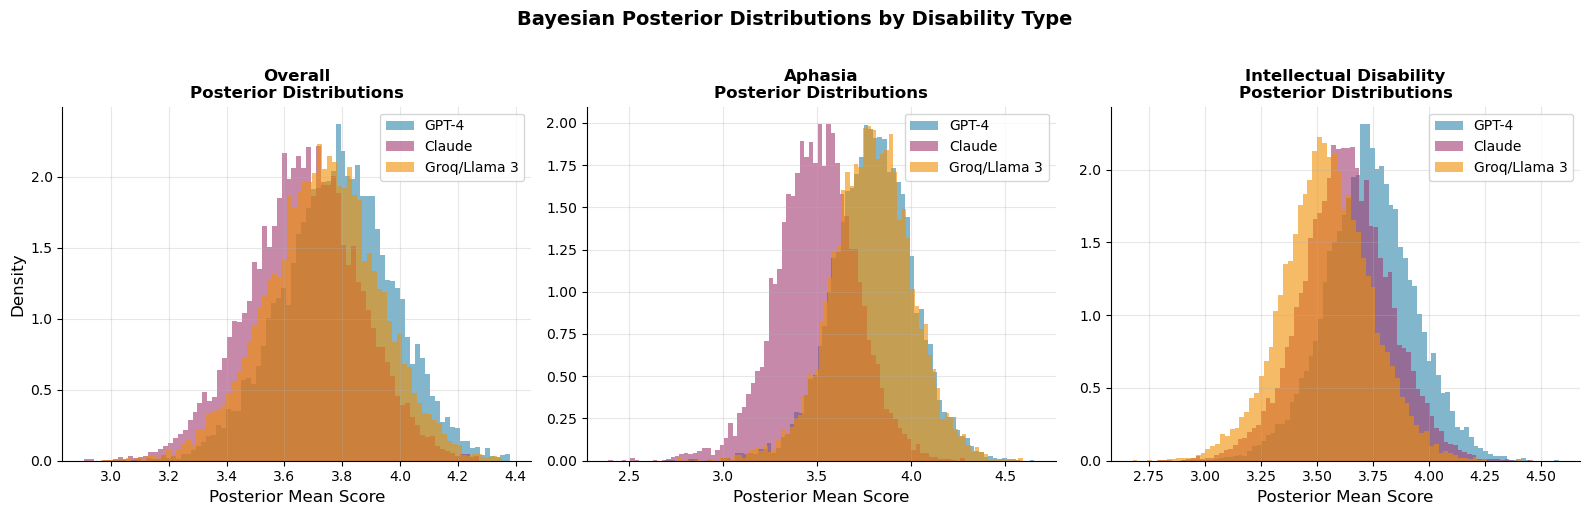

Plot 1 saved


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import arviz as az

colors = ['#2E86AB', '#A23B72', '#F18F01']
model_names_list = ['GPT-4', 'Claude', 'Groq/Llama 3']

# -----------------------------------------------
# PLOT 1: Posterior distributions
# -----------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall
posterior_mu_overall = trace.posterior['mu_model']
for i, (name, color) in enumerate(zip(model_names_list, colors)):
    samples = posterior_mu_overall.values[:, :, i].flatten()
    axes[0].hist(samples, bins=80, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('Posterior Mean Score', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Overall\nPosterior Distributions', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Aphasia
posterior_mu_aphasia = results['aphasia'].posterior['mu_model']
for i, (name, color) in enumerate(zip(model_names_list, colors)):
    samples = posterior_mu_aphasia.values[:, :, i].flatten()
    axes[1].hist(samples, bins=80, alpha=0.6, color=color, label=name, density=True)
axes[1].set_xlabel('Posterior Mean Score', fontsize=12)
axes[1].set_title('Aphasia\nPosterior Distributions', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Intellectual Disability
posterior_mu_id = trace_id.posterior['mu_model']
for i, (name, color) in enumerate(zip(model_names_list, colors)):
    samples = posterior_mu_id.values[:, :, i].flatten()
    axes[2].hist(samples, bins=80, alpha=0.6, color=color, label=name, density=True)
axes[2].set_xlabel('Posterior Mean Score', fontsize=12)
axes[2].set_title('Intellectual Disability\nPosterior Distributions', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

fig.suptitle('Bayesian Posterior Distributions by Disability Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_posteriors.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1 saved")

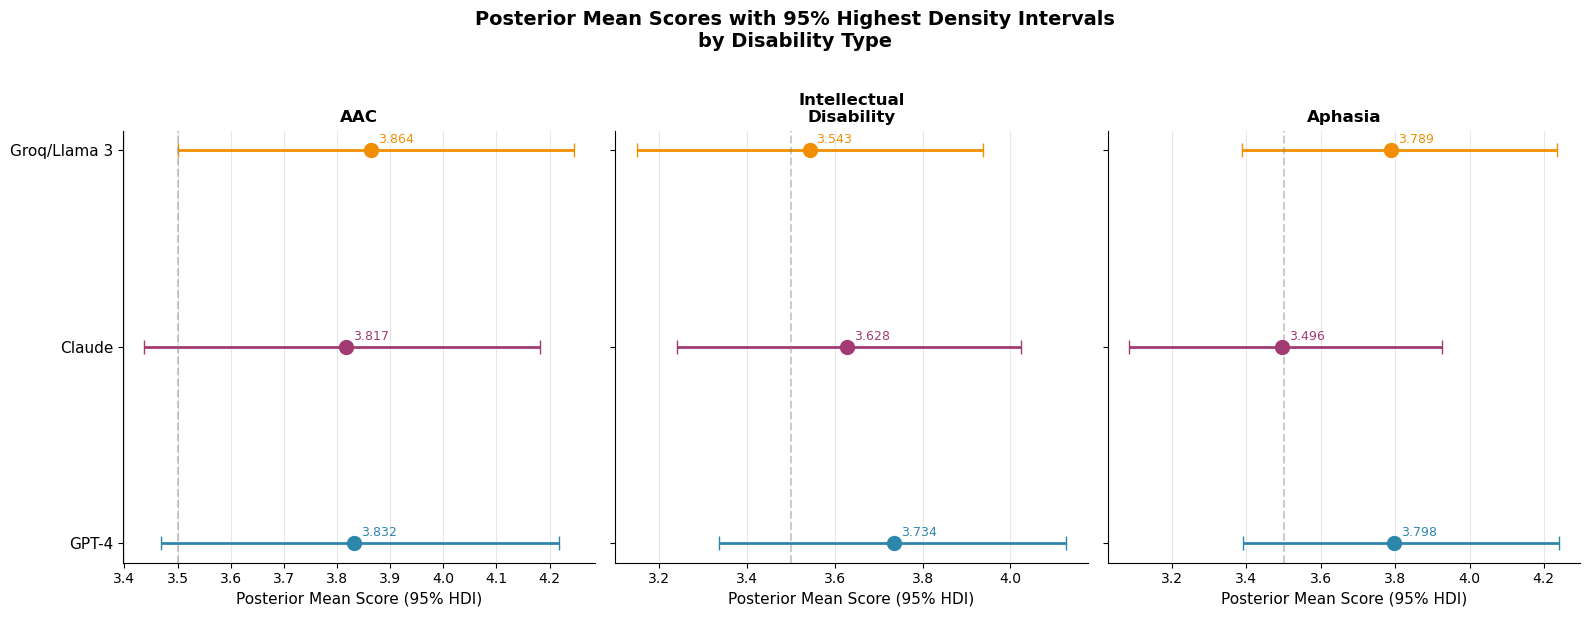

Plot 2 saved


In [18]:
# PLOT 2: Credible intervals by disability type
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

disability_data = {
    'AAC': results['AAC'],
    'Intellectual\nDisability': trace_id,
    'Aphasia': results['aphasia']
}

for ax, (disability, tr) in zip(axes, disability_data.items()):
    posterior_mu = tr.posterior['mu_model']
    
    for i, (name, color) in enumerate(zip(model_names_list, colors)):
        samples = posterior_mu.values[:, :, i].flatten()
        mean = samples.mean()
        hdi = az.hdi(samples, prob=0.95)
        
        ax.errorbar(mean, i,
                   xerr=[[mean - hdi[0]], [hdi[1] - mean]],
                   fmt='o', color=color, markersize=10,
                   capsize=5, linewidth=2, label=name)
        ax.annotate(f'{mean:.3f}',
                   xy=(mean, i),
                   xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=9, color=color)
    
    ax.set_yticks(range(3))
    ax.set_yticklabels(model_names_list, fontsize=11)
    ax.set_xlabel('Posterior Mean Score (95% HDI)', fontsize=11)
    ax.set_title(disability, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.4, label='Midpoint')

fig.suptitle('Posterior Mean Scores with 95% Highest Density Intervals\nby Disability Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_credible_intervals.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

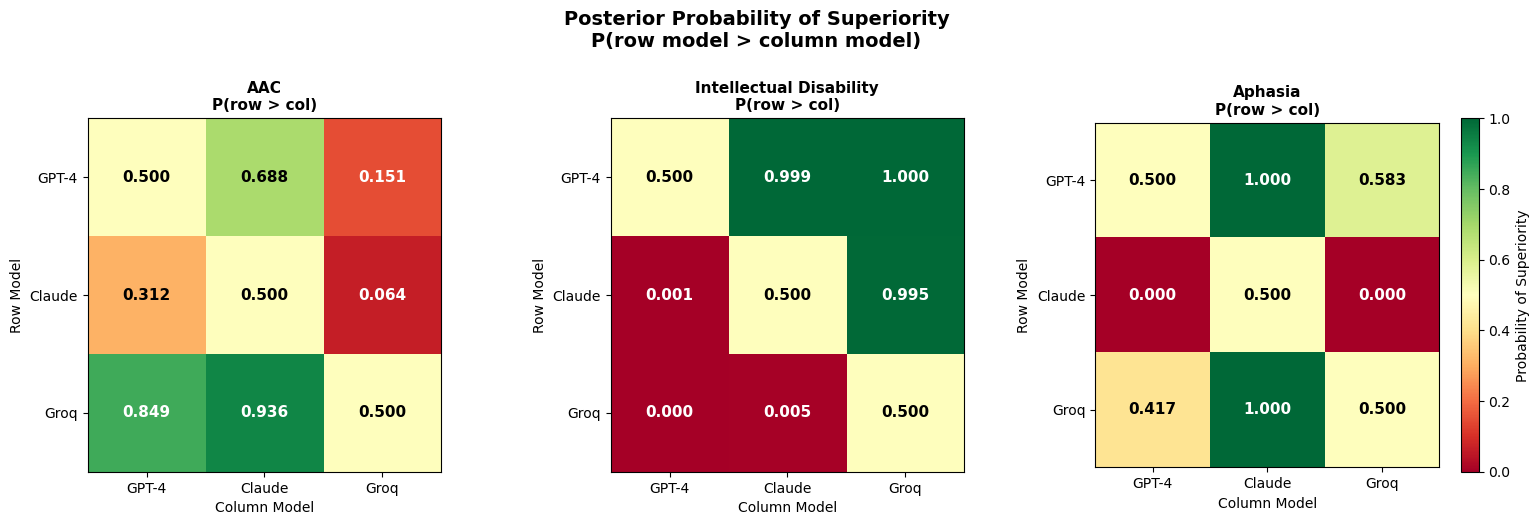

Plot 3 saved


In [19]:
# PLOT 3: Probability of superiority matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

disability_data = {
    'AAC': results['AAC'],
    'Intellectual Disability': trace_id,
    'Aphasia': results['aphasia']
}

for ax, (disability, tr) in zip(axes, disability_data.items()):
    posterior_mu = tr.posterior['mu_model']
    
    prob_matrix = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            if i != j:
                samples_i = posterior_mu.values[:, :, i].flatten()
                samples_j = posterior_mu.values[:, :, j].flatten()
                prob_matrix[i, j] = (samples_i > samples_j).mean()
            else:
                prob_matrix[i, j] = 0.5
    
    im = ax.imshow(prob_matrix, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['GPT-4', 'Claude', 'Groq'], fontsize=10)
    ax.set_yticklabels(['GPT-4', 'Claude', 'Groq'], fontsize=10)
    ax.set_xlabel('Column Model', fontsize=10)
    ax.set_ylabel('Row Model', fontsize=10)
    ax.set_title(f'{disability}\nP(row > col)', fontsize=11, fontweight='bold')
    
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{prob_matrix[i,j]:.3f}',
                   ha='center', va='center', fontsize=11,
                   color='black' if 0.3 < prob_matrix[i,j] < 0.7 else 'white',
                   fontweight='bold')

plt.colorbar(im, ax=axes[-1], label='Probability of Superiority')
fig.suptitle('Posterior Probability of Superiority\nP(row model > column model)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_probability_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3 saved")

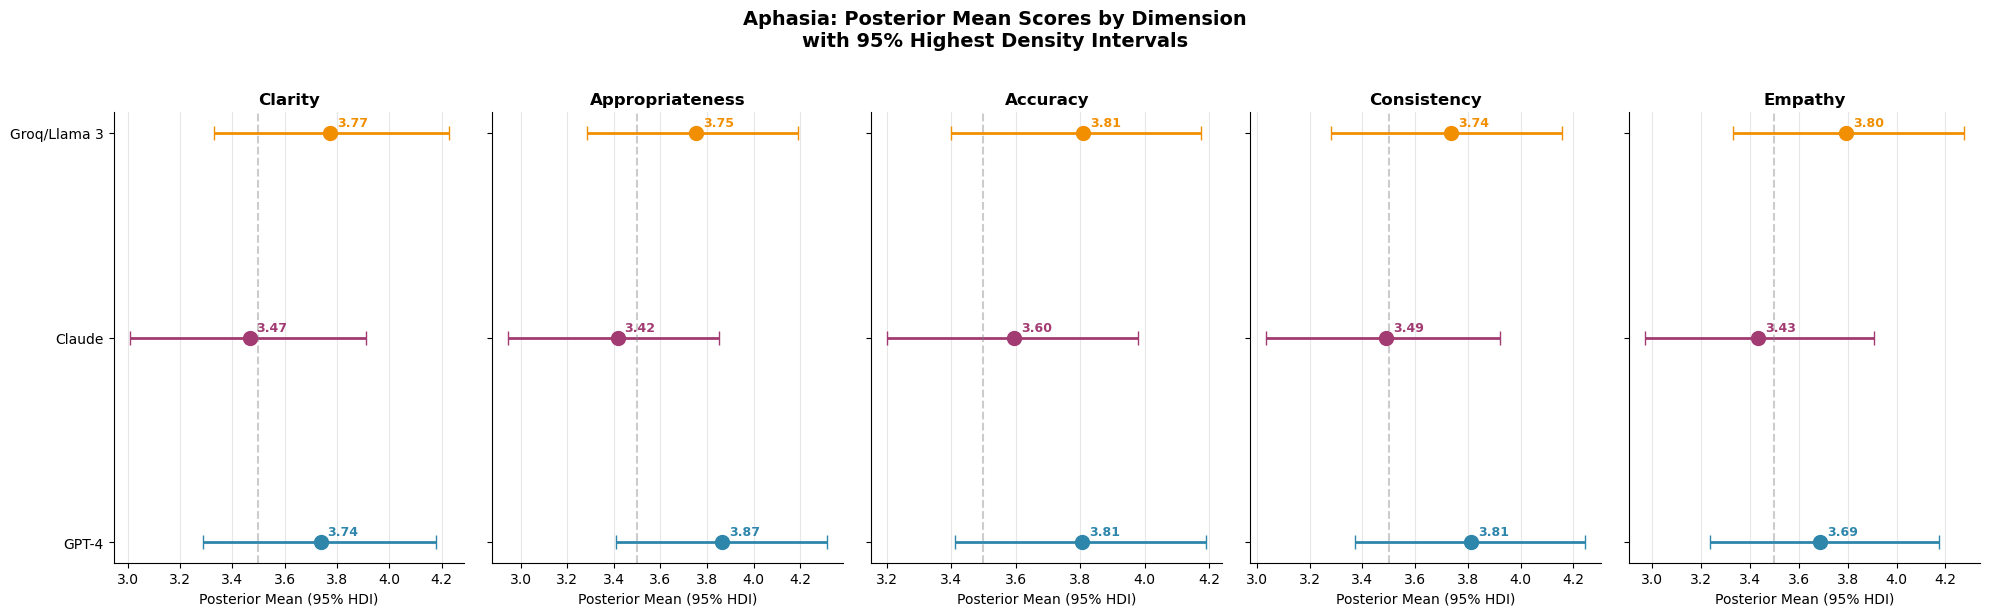

Plot 4 saved


In [20]:
# PLOT 4: Aphasia dimension breakdown
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

dimensions_display = ['Clarity', 'Appropriateness', 'Accuracy', 'Consistency', 'Empathy']
dimensions_key = ['clarity', 'appropriateness', 'accuracy', 'consistency', 'empathy']

for ax, dim_display, dim_key in zip(axes, dimensions_display, dimensions_key):
    tr = dimension_results[dim_key]
    posterior_mu = tr.posterior['mu_model']
    
    for i, (name, color) in enumerate(zip(model_names_list, colors)):
        samples = posterior_mu.values[:, :, i].flatten()
        mean = samples.mean()
        hdi = az.hdi(samples, prob=0.95)
        
        ax.errorbar(mean, i,
                   xerr=[[mean - hdi[0]], [hdi[1] - mean]],
                   fmt='o', color=color, markersize=10,
                   capsize=5, linewidth=2)
        ax.annotate(f'{mean:.2f}',
                   xy=(mean, i),
                   xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=9, color=color,
                   fontweight='bold')
    
    ax.set_yticks(range(3))
    ax.set_yticklabels(model_names_list, fontsize=10)
    ax.set_xlabel('Posterior Mean (95% HDI)', fontsize=10)
    ax.set_title(dim_display, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.4)

fig.suptitle('Aphasia: Posterior Mean Scores by Dimension\nwith 95% Highest Density Intervals',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_aphasia_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 4 saved")

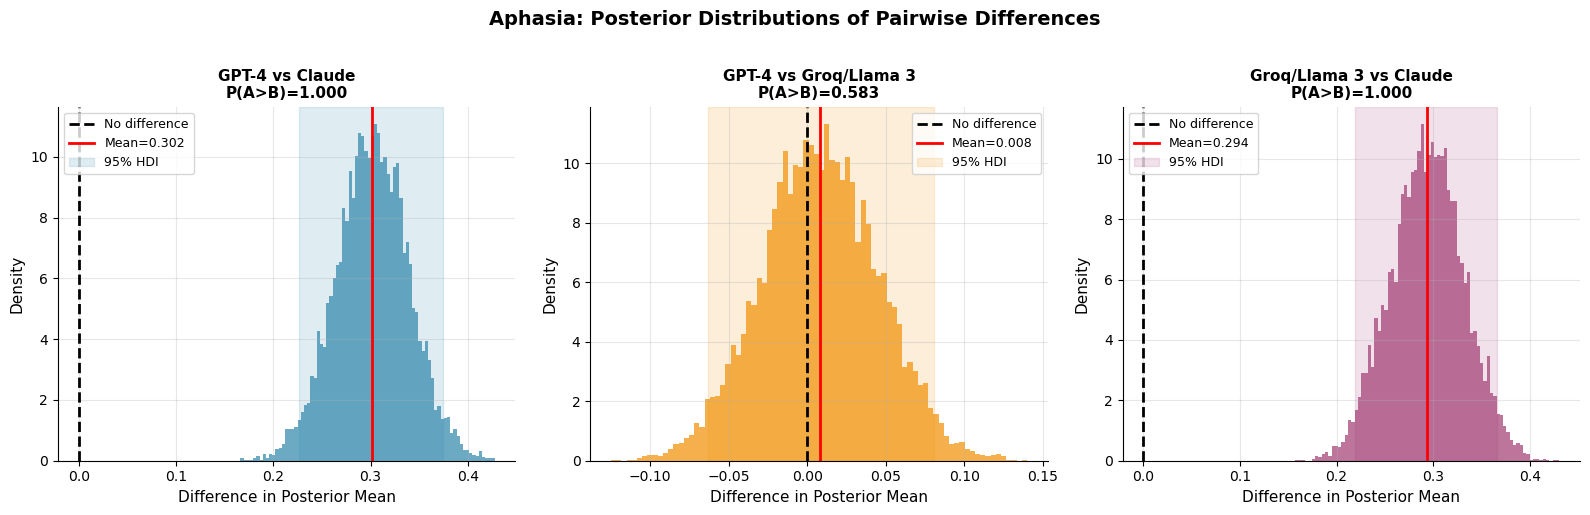

Plot 5 saved


In [21]:
# PLOT 5: Posterior difference distributions — Aphasia
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

posterior_mu_aphasia = results['aphasia'].posterior['mu_model']

pair_configs = [
    ('GPT-4 vs Claude', 0, 1, '#2E86AB'),
    ('GPT-4 vs Groq/Llama 3', 0, 2, '#F18F01'),
    ('Groq/Llama 3 vs Claude', 2, 1, '#A23B72'),
]

for ax, (label, i, j, color) in zip(axes, pair_configs):
    samples_i = posterior_mu_aphasia.values[:, :, i].flatten()
    samples_j = posterior_mu_aphasia.values[:, :, j].flatten()
    diff = samples_i - samples_j
    
    mean_diff = diff.mean()
    hdi = az.hdi(diff, prob=0.95)
    prob = (diff > 0).mean()
    
    # Plot histogram
    ax.hist(diff, bins=80, alpha=0.7, color=color, density=True)
    
    # Add vertical line at zero
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='No difference')
    
    # Add mean line
    ax.axvline(x=mean_diff, color='red', linestyle='-', linewidth=2, label=f'Mean={mean_diff:.3f}')
    
    # Shade HDI
    x_range = np.linspace(diff.min(), diff.max(), 1000)
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color=color, label=f'95% HDI')
    
    ax.set_xlabel('Difference in Posterior Mean', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{label}\nP(A>B)={prob:.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Aphasia: Posterior Distributions of Pairwise Differences',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bayesian_aphasia_differences.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 5 saved")